### <p style="text-align: center;"> **Name:** Shahzaib Khan &ensp;&ensp;&ensp;&ensp;&ensp;&ensp; **Roll No:** 19K-0273 &ensp;&ensp;&ensp;&ensp;&ensp;&ensp; **Section:** BCS-8B</p>

In [62]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [63]:
# Load dataset
data = {
    'StudyHours': ['High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High', 'Medium', 'Low', 'High'],
    'Attendance': ['High', 'High', 'Low', 'Low', 'High', 'High', 'Low', 'High', 'Low', 'High'],
    'Grades': ['Good', 'Average', 'Poor', 'Poor', 'Average', 'Poor', 'Good', 'Good', 'Poor', 'Good'],
    'Assignments': ['Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No'],
    'Class': ['P', 'P', 'F', 'F', 'P', 'F', 'P', 'P', 'F', 'P']
}
df = pd.DataFrame(data)
df.head()

,StudyHours,Attendance,Grades,Assignments,Class
0,High,High,Good,Yes,P
1,Medium,High,Average,Yes,P
2,Medium,Low,Poor,No,F
3,Low,Low,Poor,No,F
4,High,High,Average,Yes,P


In [64]:
# Encode categorical variables
encoders = {}
encoded_df = pd.DataFrame()

for col in df.columns:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = encoded_df.drop('Class', axis=1)
y = encoded_df['Class']

In [65]:
# Functions to calculate Entropy, Information Gain, Gini Index and Gini Gain
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def information_gain(X, y, feature):
    root_entropy = entropy(y)
    values, counts = np.unique(X[feature], return_counts=True)
    weighted_entropy = np.sum([(counts[i] / len(y)) * entropy(y[X[feature] == values[i]]) 
                              for i in range(len(values))])
    return root_entropy - weighted_entropy

def gini_index(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum([p**2 for p in probs])

def gini_gain(X, y, feature):
    root_gini = gini_index(y)
    values, counts = np.unique(X[feature], return_counts=True)
    weighted_gini = np.sum([(counts[i] / len(y)) * gini_index(y[X[feature] == values[i]]) 
                           for i in range(len(values))])
    return root_gini - weighted_gini

In [66]:
# Compute and print Entropy, Information Gain, Gini Index, and Gini Gain
print(f"Root Entropy: {entropy(df['Class']):.3f}")
print(f"Root Gini Index: {gini_index(df['Class'])}\n")

for feature in X.columns:
    print(f"Information Gain ({feature}): {information_gain(df, df['Class'], feature):.3f}")
    print(f"Gini Gain ({feature}): {gini_gain(df, df['Class'], feature):.3f}")

Root Entropy: 0.971
Root Gini Index: 0.48

Information Gain (StudyHours): 0.695
Gini Gain (StudyHours): 0.347
Information Gain (Attendance): 0.256
Gini Gain (Attendance): 0.163
Information Gain (Grades): 0.971
Gini Gain (Grades): 0.480
Information Gain (Assignments): 0.610
Gini Gain (Assignments): 0.320


In [67]:
# Train Entropy-based Decision Tree
entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=1, random_state=100)
entropy_model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=100)

In [68]:
# Train Gini-based Decision Tree
gini_model = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, random_state=100)
gini_model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=100)

In [69]:
# Evaluate Entropy model
y_pred_entropy = entropy_model.predict(X)
print("\nEntropy Model Results:")
print("Accuracy:", accuracy_score(y, y_pred_entropy) * 100)
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_entropy))
print("Classification Report:\n", classification_report(y, y_pred_entropy, target_names=encoders['Class'].classes_, zero_division=0))


Entropy Model Results:
Accuracy: 100.0
Confusion Matrix:
 [[4 0]
 [0 6]]
Classification Report:
               precision    recall  f1-score   support

           F       1.00      1.00      1.00         4
           P       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [70]:
# Evaluate Gini model
y_pred_gini = gini_model.predict(X)
print("\nGini Model Results:")
print("Accuracy:", accuracy_score(y, y_pred_gini) * 100)
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_gini))
print("Classification Report:\n", classification_report(y, y_pred_gini, target_names=encoders['Class'].classes_, zero_division=0))


Gini Model Results:
Accuracy: 100.0
Confusion Matrix:
 [[4 0]
 [0 6]]
Classification Report:
               precision    recall  f1-score   support

           F       1.00      1.00      1.00         4
           P       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



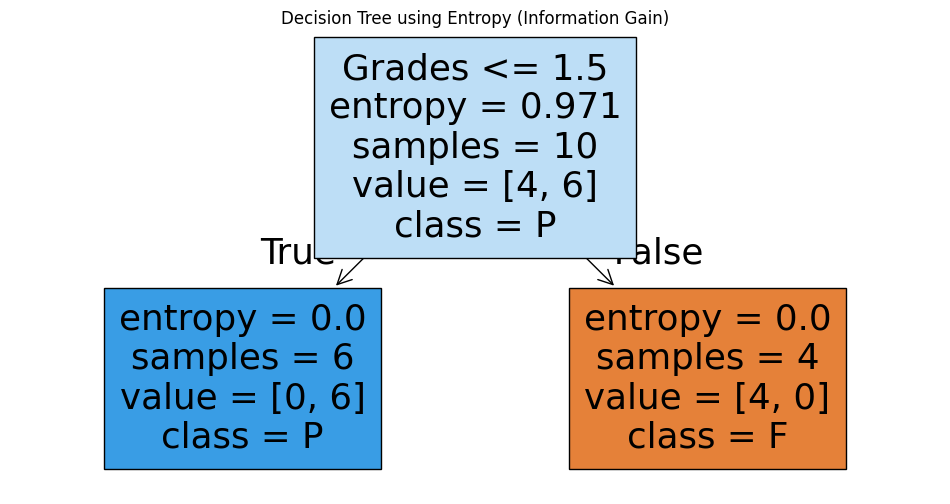

In [71]:
# Visualize Entropy-based Decision Tree
plt.figure(figsize=(12, 6))
plot_tree(entropy_model, feature_names=X.columns, class_names=encoders['Class'].classes_, filled=True)
plt.title("Decision Tree using Entropy (Information Gain)")
plt.show()

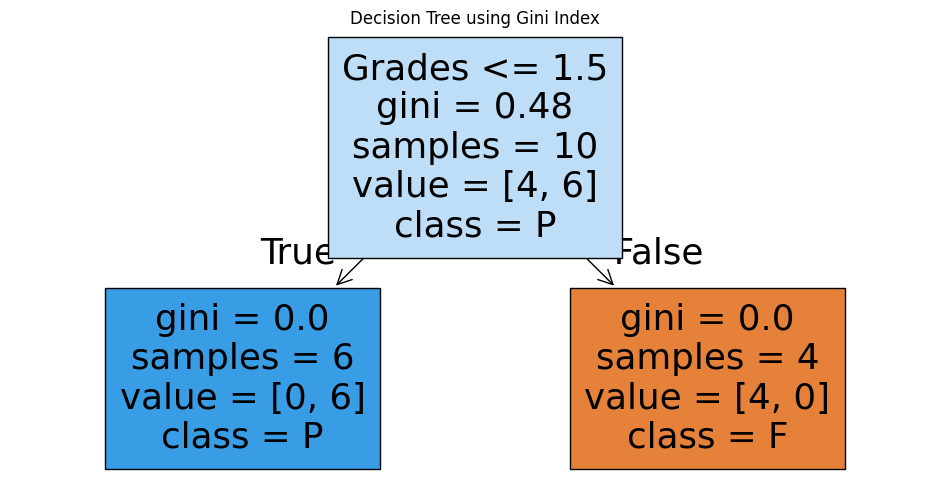

In [72]:
plt.figure(figsize=(12, 6))
plot_tree(gini_model, feature_names=X.columns, class_names=encoders['Class'].classes_, filled=True)
plt.title("Decision Tree using Gini Index")
plt.show()

**NOTE:** The dataset has only 10 instances, so no train-test split was performed. The 100% accuracy is expected since 'Grades' perfectly separates classes (Good/Average → P, Poor → F).